First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Actual_Class  
0             0  
1             0  
2             0  
3             0  
4             0  

Dataset shape: (150, 4)
Target classes: ['setosa' 'versicolor' 'virginica']

PCA explained variance ratio:
[0.72962445 0.22850762]

Training: K-Means

Training: Agglomerative

Training: DBSCAN

Training: Mean Shift

Training: BIRCH

Training: Gaussian Mixture

Training: Spectral

Training: Affinity Propagation

Clustering Validation Results:
              Algorithm  Clusters  Silhouette  Calinski_Ha

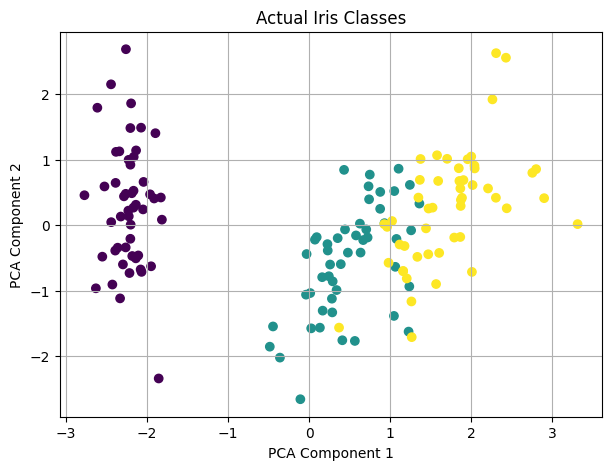

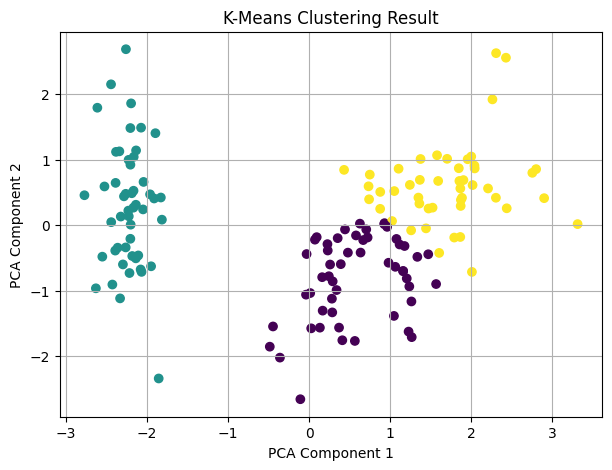

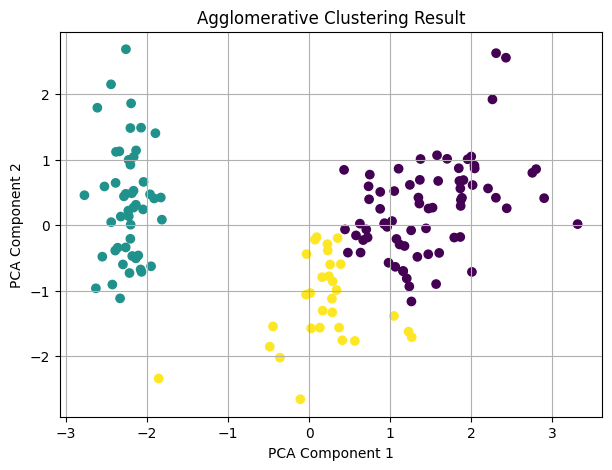

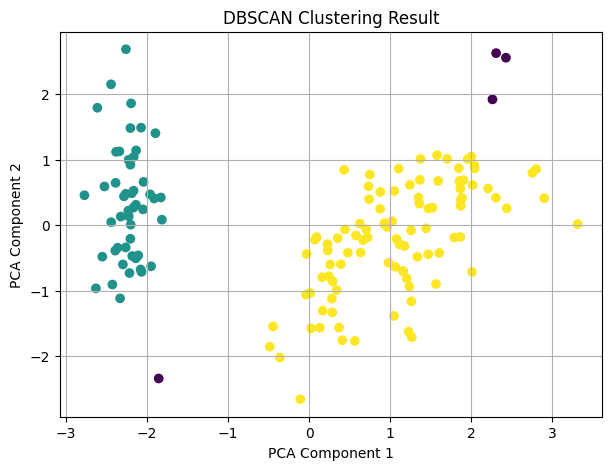

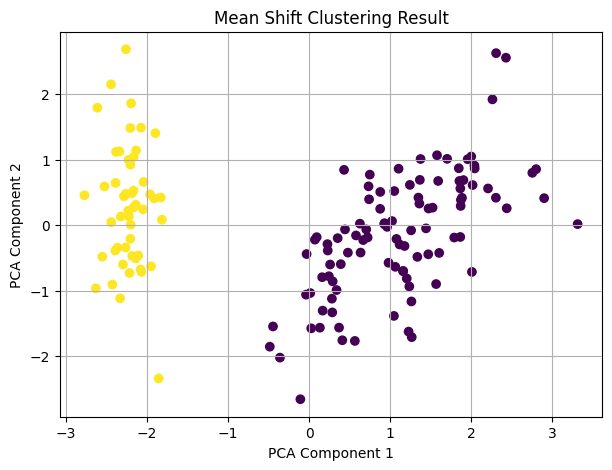

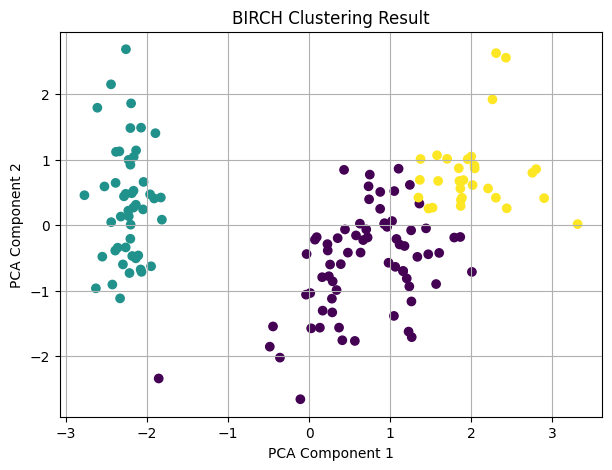

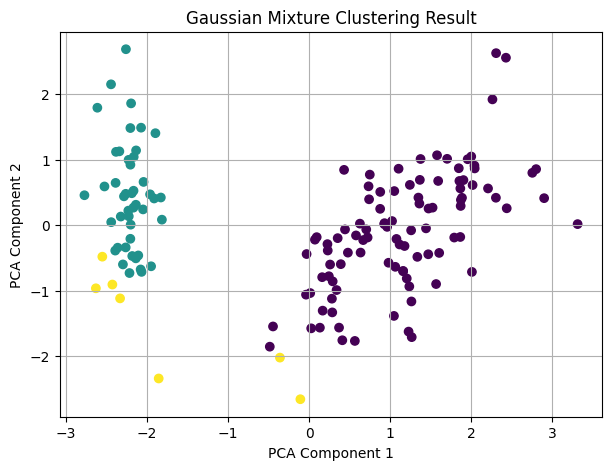

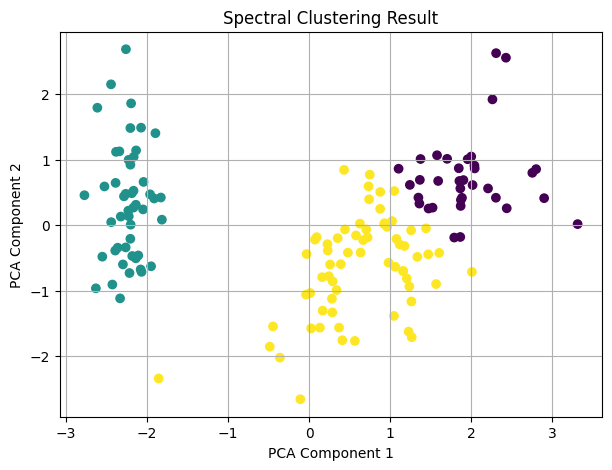

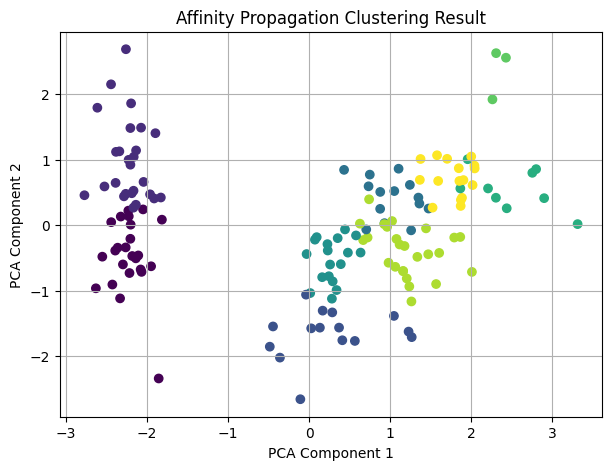

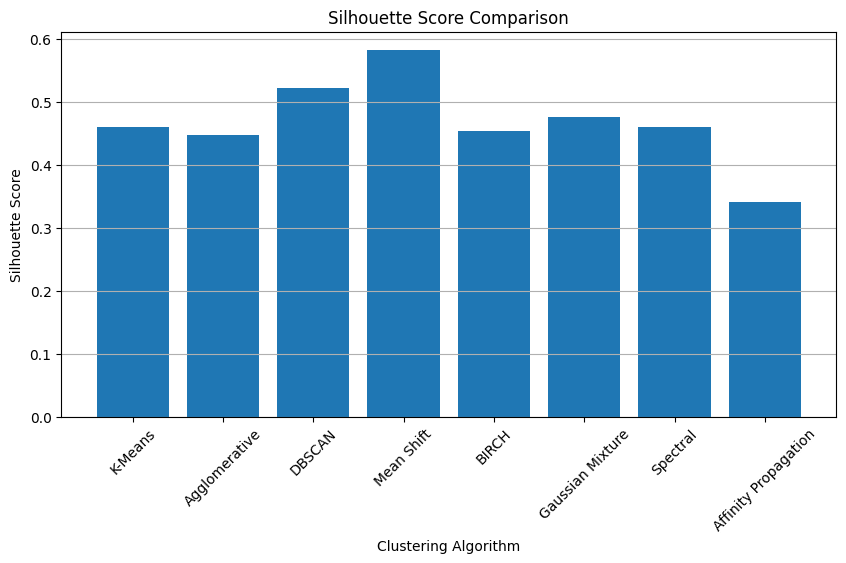

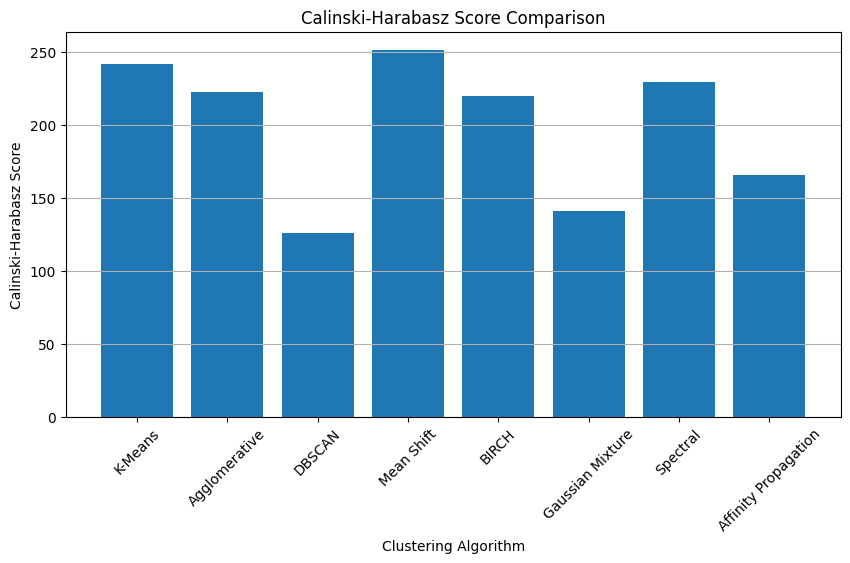

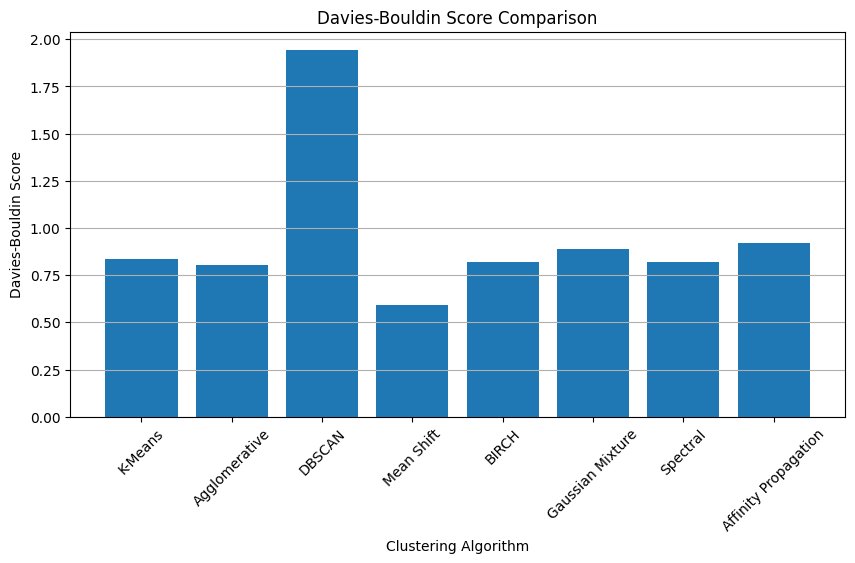

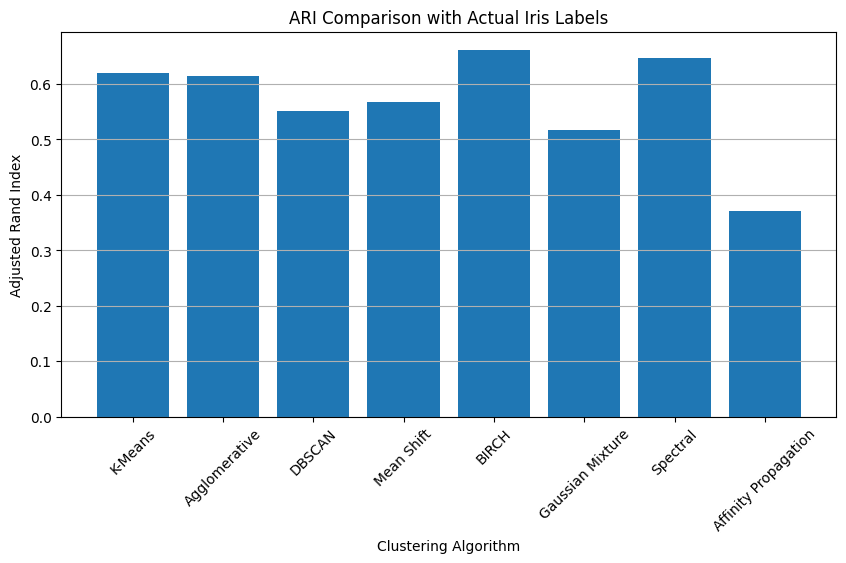

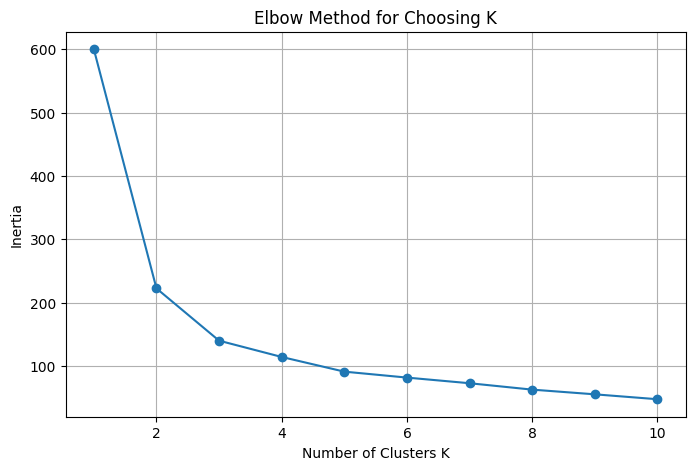

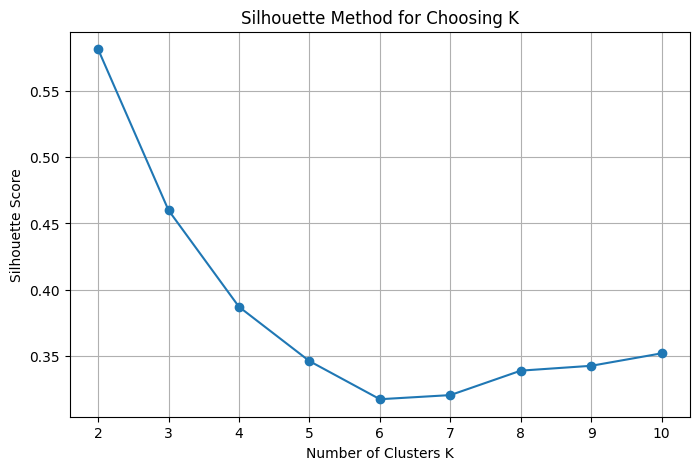

In [1]:
# ============================================================
# Beginner-Friendly Clustering Implementation
# Algorithms + Validation Metrics + Visualizations
# Dataset: Iris
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    MeanShift,
    Birch,
    SpectralClustering,
    AffinityPropagation
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# ------------------------------------------------------------
# 1. Load Iris Dataset
# ------------------------------------------------------------

iris = load_iris()
X = iris.data
y_true = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["Actual_Class"] = y_true

print("First 5 rows:")
print(df.head())

print("\nDataset shape:", X.shape)
print("Target classes:", target_names)

# ------------------------------------------------------------
# 2. Standardize Features
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 3. Reduce to 2D using PCA for visualization
# ------------------------------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nPCA explained variance ratio:")
print(pca.explained_variance_ratio_)

# ------------------------------------------------------------
# 4. Define Clustering Models
# ------------------------------------------------------------

models = {
    "K-Means": KMeans(n_clusters=3, random_state=42, n_init=10),

    "Agglomerative": AgglomerativeClustering(n_clusters=3),

    "DBSCAN": DBSCAN(eps=0.8, min_samples=5),

    "Mean Shift": MeanShift(),

    "BIRCH": Birch(n_clusters=3),

    "Gaussian Mixture": GaussianMixture(n_components=3, random_state=42),

    "Spectral": SpectralClustering(
        n_clusters=3,
        affinity="nearest_neighbors",
        random_state=42
    ),

    "Affinity Propagation": AffinityPropagation(random_state=42)
}

# ------------------------------------------------------------
# 5. Function to Evaluate Clustering
# ------------------------------------------------------------

def evaluate_clustering(X, labels, y_true):
    """
    Calculates clustering validation metrics.
    Some metrics need at least 2 clusters.
    """

    unique_labels = set(labels)

    # Remove noise label -1 from DBSCAN cluster count
    cluster_count = len(unique_labels - {-1})

    result = {
        "Clusters": cluster_count,
        "Silhouette": np.nan,
        "Calinski_Harabasz": np.nan,
        "Davies_Bouldin": np.nan,
        "ARI": adjusted_rand_score(y_true, labels),
        "NMI": normalized_mutual_info_score(y_true, labels)
    }

    if cluster_count >= 2:
        result["Silhouette"] = silhouette_score(X, labels)
        result["Calinski_Harabasz"] = calinski_harabasz_score(X, labels)
        result["Davies_Bouldin"] = davies_bouldin_score(X, labels)

    return result

# ------------------------------------------------------------
# 6. Train Models and Store Results
# ------------------------------------------------------------

results = []
cluster_outputs = {}

for name, model in models.items():

    print("\nTraining:", name)

    if name == "Gaussian Mixture":
        labels = model.fit_predict(X_scaled)
    else:
        labels = model.fit_predict(X_scaled)

    cluster_outputs[name] = labels

    metrics = evaluate_clustering(X_scaled, labels, y_true)
    metrics["Algorithm"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Algorithm",
        "Clusters",
        "Silhouette",
        "Calinski_Harabasz",
        "Davies_Bouldin",
        "ARI",
        "NMI"
    ]
]

print("\nClustering Validation Results:")
print(results_df)

# ------------------------------------------------------------
# 7. Visualize Actual Iris Classes
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Actual Iris Classes")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 8. Visualize Clusters from Each Algorithm
# ------------------------------------------------------------

for name, labels in cluster_outputs.items():

    plt.figure(figsize=(7, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(f"{name} Clustering Result")
    plt.grid(True)
    plt.show()

# ------------------------------------------------------------
# 9. Metric Comparison Visualization
# ------------------------------------------------------------

# Silhouette Score: Higher is better
plt.figure(figsize=(10, 5))
plt.bar(results_df["Algorithm"], results_df["Silhouette"])
plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Comparison")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

# Calinski-Harabasz Score: Higher is better
plt.figure(figsize=(10, 5))
plt.bar(results_df["Algorithm"], results_df["Calinski_Harabasz"])
plt.xlabel("Clustering Algorithm")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score Comparison")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

# Davies-Bouldin Score: Lower is better
plt.figure(figsize=(10, 5))
plt.bar(results_df["Algorithm"], results_df["Davies_Bouldin"])
plt.xlabel("Clustering Algorithm")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin Score Comparison")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

# ARI: Higher is better, uses actual labels
plt.figure(figsize=(10, 5))
plt.bar(results_df["Algorithm"], results_df["ARI"])
plt.xlabel("Clustering Algorithm")
plt.ylabel("Adjusted Rand Index")
plt.title("ARI Comparison with Actual Iris Labels")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

# ------------------------------------------------------------
# 10. Elbow Method for K-Means
# ------------------------------------------------------------

inertia_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 11. Silhouette Method for K-Means
# ------------------------------------------------------------

silhouette_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_values.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_values, marker="o")
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Choosing K")
plt.grid(True)
plt.show()